# Best Replacement Midfielder Finder
Using MLR gradient analysis to score all midfielders from the 3-season pool and find optimal non-Barcelona replacements for each position type.

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
print('Libraries loaded.')

Libraries loaded.


In [ ]:
# Cell 2 — Load Data
DATA = '../data/processed/'

# Load gradient file (new format with p_value, cv_std, scouting_direction)
grad_df = pd.read_csv(DATA + 'mlr_gradient_analysis.csv')
print('Gradient file columns:', list(grad_df.columns))

GRADIENT_FEATURES = list(grad_df['Feature'])
GRADIENT          = dict(zip(grad_df['Feature'], grad_df['Gradient (dy/dx)']))
P_VALUES          = dict(zip(grad_df['Feature'], grad_df['p_value']))
CV_STD            = dict(zip(grad_df['Feature'], grad_df['cv_std']))
SCOUT_DIRECTION   = dict(zip(grad_df['Feature'], grad_df['scouting_direction']))

print(f'Scouting features ({len(GRADIENT_FEATURES)}):')
for f in GRADIENT_FEATURES:
    print(f'  {f:<40} beta={GRADIENT[f]:+.3f}  {SCOUT_DIRECTION[f]}  [p={P_VALUES[f]:.3f}]')

# Barcelona per-season files (richer feature data than all_teams pool)
barca_files = [
    DATA + 'Barcelona_2012_2013_player_selected_features.csv',
    DATA + 'Barcelona_2013_2014_player_selected_features.csv',
    DATA + 'Barcelona_2014_2015_player_selected_features.csv',
]
barca_all = pd.concat([pd.read_csv(f) for f in barca_files], ignore_index=True)
barca_all['source'] = 'Barcelona'
print(f'\nBarcelona rows: {len(barca_all)}')

# Full 3-season pool — non-Barcelona teams from all_teams file
all_teams_df = pd.read_csv(DATA + 'all_teams_3seasons_player_selected_features.csv')
non_barca = all_teams_df[all_teams_df['team_name'].str.strip() != 'Barcelona'].copy()
non_barca['source'] = 'Other'
print(f'Other-teams rows: {len(non_barca)}')

# Combine: use Barcelona-specific files (complete feature data) + other teams
all_players = pd.concat([barca_all, non_barca], ignore_index=True, sort=False)
all_players['source'] = all_players['source'].fillna('Other')
print(f'Combined pool: {len(all_players)} rows, {all_players["team_name"].nunique()} teams')

missing = [f for f in GRADIENT_FEATURES if f not in all_players.columns]
print('Missing gradient features:', missing if missing else 'None — all present ✓')
print('\nNaN counts for Barcelona gradient features:')
barca_rows = all_players[all_players['source'] == 'Barcelona']
print(barca_rows[GRADIENT_FEATURES].isna().sum().to_string())

In [3]:
# Cell 3 — Aggregate Per-Player Stats (across ALL available seasons)
# Each player gets ONE row: mean of features + total matches + seasons list.
# This ensures the bypass score is computed on a stable multi-season profile,
# not averaged from per-season percentile ranks.
agg_dict = {f: 'mean' for f in GRADIENT_FEATURES}
agg_dict['bypasses_per_halftime'] = 'mean'
agg_dict['match_id']              = 'count'

player_agg = (
    all_players
    .dropna(subset=['player_name'])
    .groupby(['player_id', 'player_name', 'team_name', 'midfielder_type', 'source'])
    .agg({**agg_dict,
          'season': lambda x: ', '.join(sorted(x.unique()))})
    .reset_index()
    .rename(columns={'match_id': 'matches_played', 'season': 'seasons_played'})
)

print(f'Players (multi-season aggregate): {len(player_agg)}')
print(f'  Barcelona : {(player_agg["source"]=="Barcelona").sum()}')
print(f'  Other     : {(player_agg["source"]=="Other").sum()}')
print(f'  Feature cols used: {GRADIENT_FEATURES}')


Players (multi-season aggregate): 291
  Barcelona : 15
  Other     : 276
  Feature cols used: ['midfield_zone_coverage_x', 'final_third_entries_by_pass', 'average_position_x', 'bypass_channel_defensive_actions', 'interceptions']


In [ ]:
# Cell 4 — Gradient-Weighted Bypass Score with Bayesian Shrinkage
#
# Problem: players with few match-halves have unreliable feature estimates.
# Fix — Bayesian shrinkage toward pool mean:
#   adjusted = (n * observed + k * pool_mean) / (n + k)
#   k = pool median (data-driven prior weight)

scored = player_agg.copy()

k = scored['matches_played'].median()
print(f"Shrinkage prior k = {k:.1f} match-halves (pool median)")
print(f"Shrinkage effect by sample size:")
for n in [2, 4, 6, 12, 30, 50, 148]:
    w = n / (n + k)
    print(f"  {n:>4} match-halves → {(1-w)*100:.0f}% shrunk toward pool mean")
print()

# Apply shrinkage per feature — fill NaN with pool_mean (equiv. to n=0, full shrinkage)
for feat in GRADIENT_FEATURES:
    pool_mean = scored[feat].mean()
    n = scored['matches_played']
    feature_vals = scored[feat].fillna(pool_mean)  # NaN → pool mean (full shrinkage)
    scored[f'{feat}_shrunk'] = (n * feature_vals + k * pool_mean) / (n + k)

# Z-score shrunk features
for feat in GRADIENT_FEATURES:
    col   = f'{feat}_shrunk'
    mu    = scored[col].mean()
    sigma = scored[col].std(ddof=1)
    scored[f'z_{feat}'] = (scored[col] - mu) / (sigma if sigma > 0 else 1)

z_cols        = [f'z_{f}' for f in GRADIENT_FEATURES]
gradients_arr = np.array([GRADIENT[f] for f in GRADIENT_FEATURES])

scored['raw_bypass_score'] = scored[z_cols].values @ gradients_arr
scored['bypass_score']     = scored['raw_bypass_score'].rank(pct=True) * 100

type_labels = {0: 'DM (Defensive Mid)', 1: 'CM (Central Mid)', 2: 'AM (Attacking Mid)'}
scored['position_label'] = scored['midfielder_type'].map(type_labels)

print("Score distribution (shrinkage-adjusted):")
print(scored['bypass_score'].describe().round(2))
print()
print(f"{'Feature':<38} {'gradient':>9}  Direction")
print('-' * 60)
for f in GRADIENT_FEATURES:
    print(f"  {f:<36} {GRADIENT[f]:>9.4f}  {SCOUT_DIRECTION[f]}")

In [ ]:
# Cell 5 — Barcelona Squad Assessment
# Flag players as WEAK if their bypass_score is above the position-type median.
barca_scored = scored[scored['source'] == 'Barcelona'].copy()

# Position-level median threshold
pos_median = barca_scored.groupby('midfielder_type')['bypass_score'].median().to_dict()
barca_scored['pos_median'] = barca_scored['midfielder_type'].map(pos_median)
barca_scored['status']     = barca_scored.apply(
    lambda r: 'WEAK' if r['bypass_score'] > r['pos_median'] else 'KEEP', axis=1
)

barca_players = barca_scored.copy()

print('=== Barcelona Midfielder Assessment ===')
print('(Threshold: above position-type median = WEAK)')
print()
for mtype in sorted(barca_players['midfielder_type'].unique()):
    label  = type_labels.get(mtype, str(mtype))
    subset = barca_players[barca_players['midfielder_type'] == mtype].sort_values('bypass_score')
    med    = pos_median[mtype]
    print(f"--- {label}  (median threshold = {med:.1f}) ---")
    for _, row in subset.iterrows():
        flag = "  ⚠ WEAK" if row['status'] == 'WEAK' else "  ✓ KEEP"
        print(f"  {row['player_name']:<35}  score={row['bypass_score']:5.1f}  "
              f"matches={row['matches_played']:3.0f}  {flag}")
    print()

weak_players = barca_players[barca_players['status'] == 'WEAK'].reset_index(drop=True)
print(f"Weak players flagged for replacement: {len(weak_players)}")
print(weak_players[['player_name','midfielder_type','bypass_score','matches_played','seasons_played']].to_string(index=False))

In [ ]:
# Cell 6 — Find Top Replacements Per Weak Barcelona Player
# Rank candidates by raw_bypass_score (gradient-weighted feature composite)
# NOT by pool percentile — percentile depends on who is in the pool.
MIN_MATCHES  = 4
MIN_BYPASSES = 3
TOP_N        = 5

candidates = scored[
    (scored['source']       == 'Other') &
    (scored['midfielder_type'].isin([0, 1, 2])) &
    (scored['matches_played'] >= MIN_MATCHES) &
    (scored['bypasses_per_halftime'] >= MIN_BYPASSES)
].copy()

print(f"Candidate pool (min {MIN_MATCHES} matches, avg bypasses >= {MIN_BYPASSES}): {len(candidates)} players")
print(f"Ranking by: raw_bypass_score (gradient × z-score of {GRADIENT_FEATURES})")

replacement_map = {}

for _, weak in weak_players.iterrows():
    mtype     = weak['midfielder_type']
    label     = type_labels.get(mtype, str(mtype))
    weak_raw  = weak['raw_bypass_score']

    pool = candidates[
        (candidates['midfielder_type']  == mtype) &
        (candidates['raw_bypass_score'] < weak_raw)   # better composite than this player
    ].sort_values('raw_bypass_score').head(TOP_N).copy()

    pool['replaces']        = weak['player_name']
    pool['barca_raw_score'] = weak_raw
    pool['improvement']     = weak_raw - pool['raw_bypass_score']   # higher = bigger improvement
    replacement_map[weak['player_name']] = pool

    print(f"\n=== Replace {weak['player_name']} ({label}, raw={weak_raw:.4f}) ===")
    if pool.empty:
        print("  No qualifying candidates found in current pool.")
    else:
        show_cols = ['player_name', 'team_name', 'raw_bypass_score',
                     'bypasses_per_halftime', 'matches_played', 'seasons_played', 'improvement']
        for f in GRADIENT_FEATURES:
            show_cols.append(f)
        print(pool[show_cols].to_string(index=False))

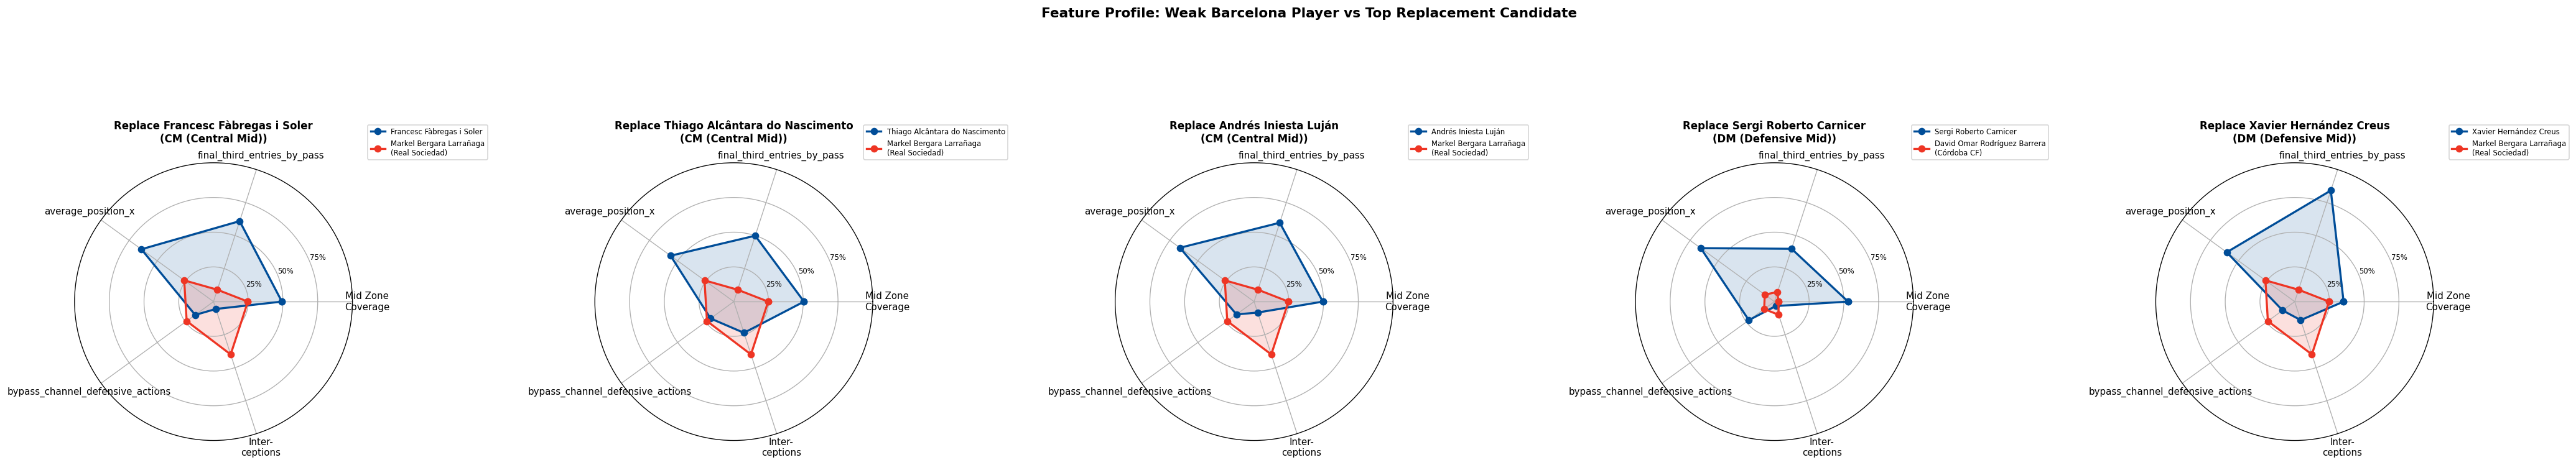

Radar chart saved.


In [7]:
# Cell 7 — Radar Charts: weak Barcelona player vs their top replacement
feature_mins = scored[GRADIENT_FEATURES].min()
feature_maxs = scored[GRADIENT_FEATURES].max()

def minmax_norm(row, features, mins, maxs):
    vals = []
    for f in features:
        r = maxs[f] - mins[f]
        vals.append((row[f] - mins[f]) / r if r > 0 else 0.5)
    return vals

short_labels = {
    'midfield_zone_coverage_x': 'Mid Zone\nCoverage',
    'possessions_involved':     'Poss\nInvolved',
    'interceptions':            'Inter-\nceptions',
}
radar_labels = [short_labels.get(f, f) for f in GRADIENT_FEATURES]

n      = len(GRADIENT_FEATURES)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]

barca_color = '#004D98'
repl_color  = '#EE3524'

# One chart per weak Barcelona player who has a replacement
chartable = [(name, pool) for name, pool in replacement_map.items() if not pool.empty]
N_CHARTS  = len(chartable)

if N_CHARTS == 0:
    print("No weak players with replacements to chart.")
else:
    fig, axes = plt.subplots(1, N_CHARTS, figsize=(7*N_CHARTS, 7), subplot_kw=dict(polar=True))
    if N_CHARTS == 1:
        axes = [axes]

    for ax_idx, (weak_name, pool) in enumerate(chartable):
        ax = axes[ax_idx]

        # Weak Barcelona player row (avg across seasons)
        barca_row = barca_scored[barca_scored['player_name'] == weak_name]
        if barca_row.empty:
            continue
        barca_feat = barca_row[GRADIENT_FEATURES].mean()

        # Top replacement candidate row
        top_cand = pool.iloc[0]
        cand_row = scored[scored['player_name'] == top_cand['player_name']]
        if cand_row.empty:
            continue
        cand_feat = cand_row[GRADIENT_FEATURES].mean()

        for name, feat_row, color in [
            (weak_name, barca_feat, barca_color),
            (f"{top_cand['player_name']}\n({top_cand['team_name']})", cand_feat, repl_color),
        ]:
            vals  = minmax_norm(feat_row, GRADIENT_FEATURES, feature_mins, feature_maxs)
            vals += vals[:1]
            ax.plot(angles, vals, "o-", linewidth=2, color=color, label=name)
            ax.fill(angles, vals, alpha=0.15, color=color)

        mtype = weak_players[weak_players['player_name'] == weak_name]['midfielder_type'].values[0]
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(radar_labels, size=9)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75])
        ax.set_yticklabels(["25%","50%","75%"], size=7)
        ax.set_title(f"Replace {weak_name}\n({type_labels.get(mtype,'')})",
                     size=10, fontweight="bold", pad=20)
        ax.legend(loc="upper right", bbox_to_anchor=(1.5, 1.15), fontsize=7)

    fig.suptitle("Feature Profile: Weak Barcelona Player vs Top Replacement Candidate",
                 size=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(DATA + "best_replacement_radar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Radar chart saved.")


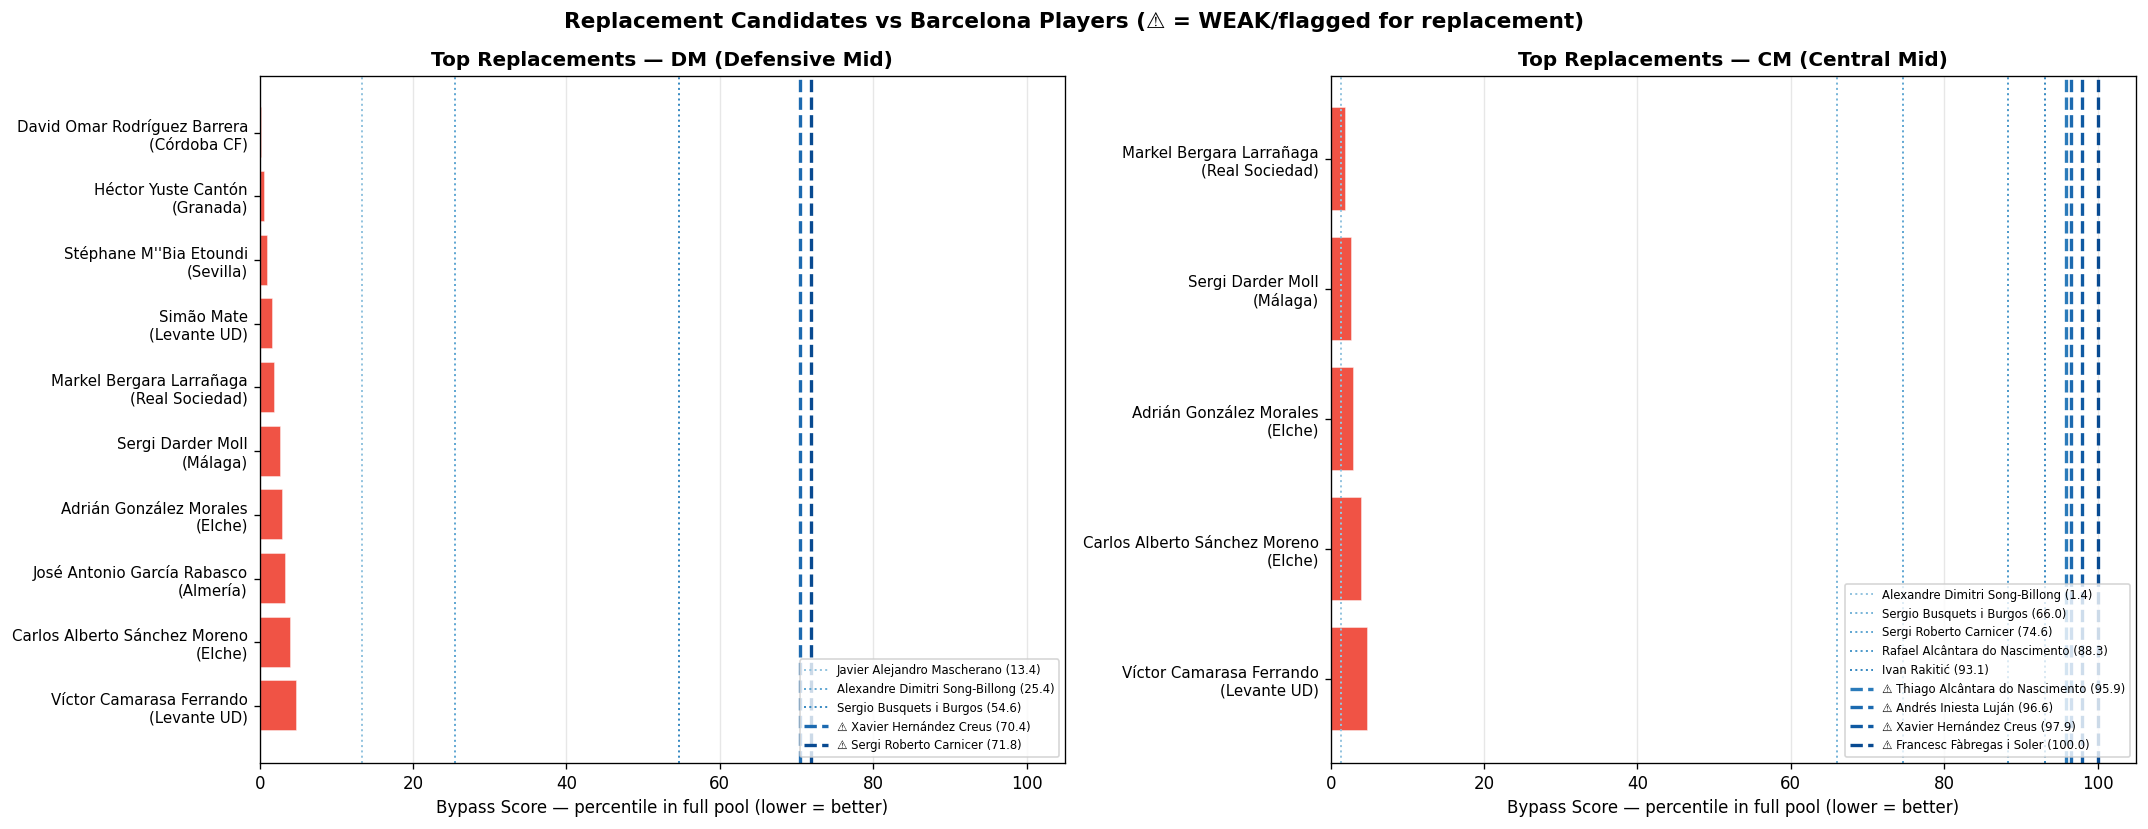

Score bar chart saved.


In [8]:
# Cell 8 — Score Bar Chart: weak Barcelona players and their top replacement per position
barca_player_scores = (
    barca_players[["midfielder_type","player_name","bypass_score","raw_bypass_score","status"]]
    .sort_values(["midfielder_type","bypass_score"])
)

active_types = sorted(weak_players["midfielder_type"].unique())
N_TYPES = len(active_types)
if N_TYPES == 0:
    print("No weak players to chart.")
else:
    fig, axes = plt.subplots(1, N_TYPES, figsize=(9*N_TYPES, 7))
    if N_TYPES == 1:
        axes = [axes]

    for ax_idx, mtype in enumerate(active_types):
        ax = axes[ax_idx]
        label = type_labels.get(mtype, str(mtype))

        weak_of_type = weak_players[weak_players["midfielder_type"] == mtype]["player_name"].tolist()
        all_cands = pd.concat(
            [replacement_map[p] for p in weak_of_type if not replacement_map.get(p, pd.DataFrame()).empty],
            ignore_index=True
        ).drop_duplicates("player_name").sort_values("bypass_score").head(10)

        if all_cands.empty:
            ax.text(0.5, 0.5, "No candidates", ha="center", va="center", transform=ax.transAxes)
            continue

        bar_labels = all_cands["player_name"] + "\n(" + all_cands["team_name"] + ")"
        ax.barh(range(len(all_cands)), all_cands["bypass_score"],
                color="#EE3524", edgecolor="white", alpha=0.85)
        ax.set_yticks(range(len(all_cands)))
        ax.set_yticklabels(bar_labels, fontsize=9)
        ax.invert_yaxis()

        barca_type = barca_player_scores[barca_player_scores["midfielder_type"] == mtype]
        blue_cmap  = plt.cm.Blues
        n_b = len(barca_type)
        for i, (_, brow) in enumerate(barca_type.sort_values("bypass_score").iterrows()):
            shade = blue_cmap(0.4 + 0.5 * i / max(n_b-1, 1))
            style = "--" if brow["status"] == "WEAK" else ":"
            lw    = 2.0 if brow["status"] == "WEAK" else 1.2
            ax.axvline(brow["bypass_score"], color=shade, linestyle=style, linewidth=lw,
                       label=f"{'⚠ ' if brow['status']=='WEAK' else ''}{brow['player_name']} ({brow['bypass_score']:.1f})")

        ax.set_xlabel("Bypass Score — percentile in full pool (lower = better)", fontsize=10)
        ax.set_title(f"Top Replacements — {label}", fontsize=12, fontweight="bold")
        ax.set_xlim(0, 105)
        ax.grid(axis="x", alpha=0.3)
        ax.legend(fontsize=7, loc="lower right")

    fig.suptitle("Replacement Candidates vs Barcelona Players (⚠ = WEAK/flagged for replacement)",
                 size=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(DATA + "best_replacement_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Score bar chart saved.")


In [ ]:
# Cell 9 — Final Recommendation Summary
print("=" * 70)
print("TRANSFER RECOMMENDATIONS — NEXT SEASON")
print("Ranked by gradient-weighted feature composite (raw_bypass_score).")
print("Lower raw score = better feature profile on identified scouting criteria.")
print("=" * 70)

for _, weak in weak_players.sort_values(["midfielder_type", "bypass_score"]).iterrows():
    mtype = weak["midfielder_type"]
    label = type_labels.get(mtype, str(mtype))
    pool  = replacement_map.get(weak["player_name"], pd.DataFrame())

    print(f"\n{'─'*70}")
    print(f"  REPLACE : {weak['player_name']}")
    print(f"  Position: {label}  |  Bypass score: {weak['bypass_score']:.1f}  "
          f"|  Raw composite: {weak['raw_bypass_score']:.4f}")
    print(f"  Matches : {weak['matches_played']:.0f}  |  Seasons: {weak['seasons_played']}")
    print(f"  Avg bypasses conceded per half: {weak['bypasses_per_halftime']:.2f}")
    print(f"  Feature profile:")
    for f in GRADIENT_FEATURES:
        direction = SCOUT_DIRECTION[f]
        val = weak[f]
        print(f"    {f:<38} = {val:.3f}  ({direction})")
    print(f"{'─'*70}")

    if pool.empty:
        print("  No qualifying replacement found in current data.")
    else:
        print(f"  {'Rank':<5} {'Player':<30} {'Team':<22} {'Raw Score':>10} {'Improvement':>12}  Seasons")
        for rank, (_, row) in enumerate(pool.iterrows(), 1):
            print(f"  {rank:<5} {row['player_name']:<30} {row['team_name']:<22} "
                  f"{row['raw_bypass_score']:>10.4f} {row['improvement']:>+12.4f}  {row['seasons_played']}")
        # Show top candidate feature profile
        top = pool.iloc[0]
        print(f"\n  Top candidate feature profile ({top['player_name']}):")
        for f in GRADIENT_FEATURES:
            direction = SCOUT_DIRECTION[f]
            barca_val = weak[f]
            cand_val  = top[f]
            diff      = cand_val - barca_val
            print(f"    {f:<38} = {cand_val:.3f}  (Barca: {barca_val:.3f}, Δ={diff:+.3f})")

print("\n" + "=" * 70)

# Save
rows = []
for _, weak in weak_players.iterrows():
    pool = replacement_map.get(weak["player_name"], pd.DataFrame())
    for rank, (_, row) in enumerate(pool.iterrows(), 1):
        entry = {
            "weak_barca_player":   weak["player_name"],
            "position":            type_labels.get(weak["midfielder_type"], ""),
            "barca_bypass_score":  round(weak["bypass_score"], 2),
            "barca_raw_score":     round(weak["raw_bypass_score"], 4),
            "rank":                rank,
            "candidate_name":      row["player_name"],
            "candidate_team":      row["team_name"],
            "candidate_raw_score": round(row["raw_bypass_score"], 4),
            "improvement":         round(row["improvement"], 4),
            "candidate_seasons":   row["seasons_played"],
            "candidate_matches":   row["matches_played"],
        }
        for f in GRADIENT_FEATURES:
            entry[f"barca_{f}"]  = round(weak[f], 4)
            entry[f"cand_{f}"]   = round(row[f], 4)
        rows.append(entry)

if rows:
    rec_df = pd.DataFrame(rows)
    rec_df.to_csv(DATA + "transfer_recommendations.csv", index=False)
    print(f"Saved {len(rows)} recommendations to transfer_recommendations.csv")